In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import datetime as dt

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("pytorch-lifestream/rosbank-churn", "train")
train = ds['train']
df: pd.DataFrame = train.to_pandas() # type: ignore

/home/lenar/ashdagasd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(df.shape)
df['TRDATETIME'] = pd.to_datetime(df['TRDATETIME'], format="%d%b%y:%X")
df["DOW"] = df["TRDATETIME"].dt.day_of_week
df.head()

(490513, 10)


,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,DOW
0,01/10/2017,0,5200,None,810,2017-10-21 00:00:00,5023.0,POS,0,0.0,5
1,01/10/2017,0,6011,None,810,2017-10-12 12:24:07,20000.0,DEPOSIT,0,0.0,3
2,01/12/2017,0,5921,None,810,2017-12-05 00:00:00,767.0,POS,0,0.0,1
3,01/10/2017,0,5411,None,810,2017-10-21 00:00:00,2031.0,POS,0,0.0,5
4,01/10/2017,0,6012,None,810,2017-10-24 13:14:24,36562.0,C2C_OUT,0,0.0,1


In [3]:
(df["TRDATETIME"].dt.time != dt.time(0,0,0)).sum()

np.int64(57893)

In [4]:
df["date"] = df["TRDATETIME"].dt.date.astype("datetime64[ns]")
df.head()

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,DOW,date
0,01/10/2017,0,5200,None,810,2017-10-21 00:00:00,5023.0,POS,0,0.0,5,2017-10-21
1,01/10/2017,0,6011,None,810,2017-10-12 12:24:07,20000.0,DEPOSIT,0,0.0,3,2017-10-12
2,01/12/2017,0,5921,None,810,2017-12-05 00:00:00,767.0,POS,0,0.0,1,2017-12-05
3,01/10/2017,0,5411,None,810,2017-10-21 00:00:00,2031.0,POS,0,0.0,5,2017-10-21
4,01/10/2017,0,6012,None,810,2017-10-24 13:14:24,36562.0,C2C_OUT,0,0.0,1,2017-10-24


In [5]:
# Количество различных значений признаков

df.nunique()

PERIOD             19
cl_id            5000
MCC               344
channel_type        5
currency           59
TRDATETIME      58113
amount          85817
trx_category       10
target_flag         2
target_sum       2651
DOW                 7
date              543
dtype: int64

In [6]:
df.isna().sum()

PERIOD             0
cl_id              0
MCC                0
channel_type    2910
currency           0
TRDATETIME         0
amount             0
trx_category       0
target_flag        0
target_sum         0
DOW                0
date               0
dtype: int64

In [7]:
df.target_flag.value_counts()

target_flag
1    320103
0    170410
Name: count, dtype: int64

In [8]:
(df.currency.value_counts() / df.shape[0]).head()

currency
810    0.973764
978    0.011286
840    0.003916
933    0.001144
985    0.000862
Name: count, dtype: float64

In [9]:
df = df[df.currency == 810]
df = df.drop(["currency"], axis=1)
df.shape

(477644, 11)

In [10]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_theme('notebook')

[Text(0.5, 1.0, 'Средний объем транзакции по дням недели')]

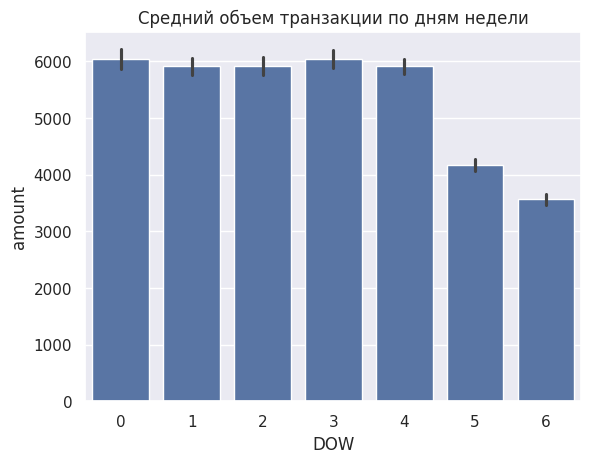

In [11]:
ax = sns.barplot(df, x="DOW", y="amount")
ax.set(title="Средний объем транзакции по дням недели")

[Text(0.5, 0, 'std суток между транзакциями по клиентам')]

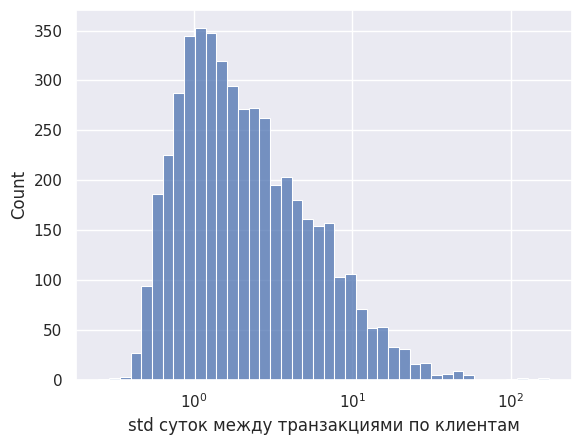

In [12]:
df = df.sort_values(["cl_id", "date"])

df["date_diff"] = df.groupby("cl_id")["date"].diff()

ax = sns.histplot(df.groupby("cl_id")["date_diff"].std().dt.total_seconds()/3600/24, log_scale=True)

ax.set(xlabel="std суток между транзакциями по клиентам")

<Axes: xlabel='Count', ylabel='TRDATETIME'>

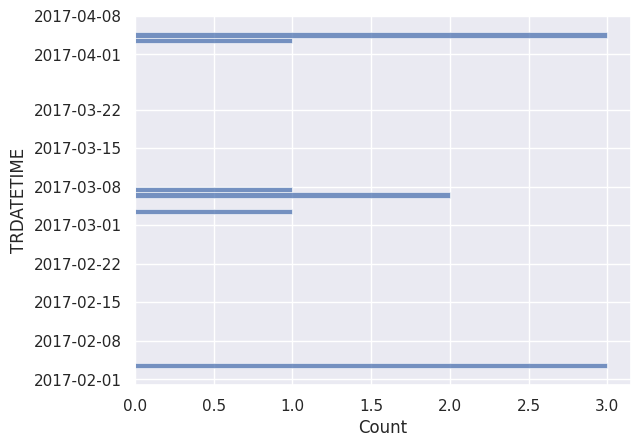

In [13]:
sns.histplot(y=df["TRDATETIME"][df.cl_id == 24], binwidth=1)

In [14]:
transactions = df.cl_id.value_counts()
grouper = df.groupby("cl_id")
days = (grouper['TRDATETIME'].max() - grouper['TRDATETIME'].min()).dt.total_seconds()/3600/24 + 1

print("Статистики количества транзакций\n", transactions.describe(), "\n")
print("Статистики длины временного отрезка\n", days.describe())

Статистики количества транзакций
 count    4961.000000
mean       96.279782
std        77.190168
min         1.000000
25%        33.000000
50%        81.000000
75%       142.000000
max       784.000000
Name: count, dtype: float64 

Статистики длины временного отрезка
 count    4961.000000
mean       80.858948
std        31.645072
min         1.000000
25%        74.814410
50%        89.000000
75%        92.518542
max       481.003981
Name: TRDATETIME, dtype: float64


<Axes: ylabel='count'>

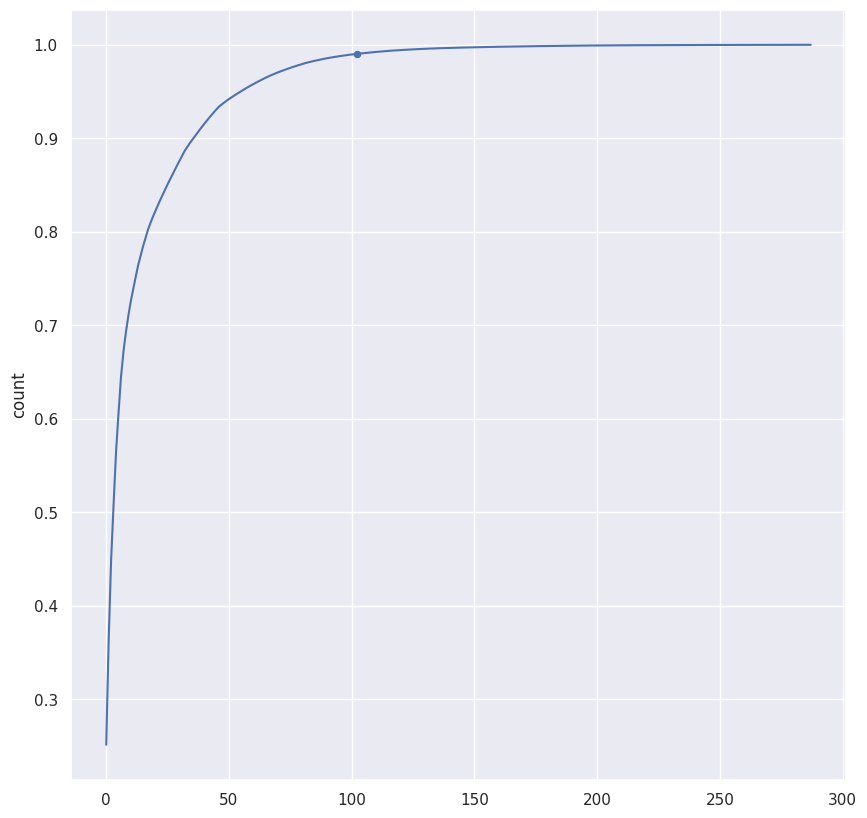

In [45]:
plt.figure(figsize=(10, 10))

mcc_weights = df["MCC"].value_counts() / df["MCC"].shape[0]
mcc_weights = mcc_weights.cumsum().reset_index(drop=True)

threshold = 0.99

x = mcc_weights.searchsorted(threshold)
sns.lineplot(mcc_weights)
sns.scatterplot(x=[x], y=[threshold])